# Candidate list comparison

Compare peptide sequences from a **generated** `final_candidates.csv` run against the original paper PDDP table (`Candidates Table 6 - Database of PDDPs.csv`).

Reports:

- **Exact matches** — paper sequence appears verbatim in the generated set
- **Near matches** — same core sequence with a few extra or missing residues (substring containment within a configurable length delta)

Edit paths in the first code cell, then run all cells. The final cell runs a small test suite and prints a pass/fail summary.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("../sequence_to_svm_minimal").expanduser().resolve()

# --- edit these paths (relative to PROJECT_ROOT unless absolute) ---
GENERATED_CSV = "data/proteomes/pane_filtered_candidates/generated/7-2-198K/final_candidates.csv"
PAPER_CSV = "data/proteomes/original_paper/Candidates Table 6 - Database of PDDPs.csv"
# GENERATED_CSV ="data/test/mass_spec/generated/mass-spec-data - peptides.csv"
# PAPER_CSV = "data/test/mass_spec/generated/setC_min2_both_conditions_no_proteasome (1).csv"


GENERATED_SEQUENCE_COL = ["Sequence", "sequence"]
PAPER_SEQUENCE_COL = "Sequence"

# Max |len(paper) - len(generated)| for a near match (substring containment).
# Set to 40 to catch all possible substring matches (since max length is 50 and min is 10)
MAX_NEAR_MATCH_DELTA = 40

# Optional minimum overlap rates for informational assertions (set None to skip).
MIN_EXACT_MATCH_RATE: float | None = None
MIN_COMBINED_COVERAGE_RATE: float | None = None


def _resolve(path_str: str) -> Path:
    p = Path(path_str).expanduser()
    if not p.is_absolute():
        p = PROJECT_ROOT / p
    return p.resolve()


def normalize_sequence(value) -> str:
    return str(value).strip().upper()


def load_generated_sequences(path: Path, columns: list[str] = GENERATED_SEQUENCE_COL) -> pd.Series:
    # usecols in read_csv expects a callable if we want to flexibly match one of several possible columns
    def col_matcher(col_name: str) -> bool:
        return col_name in columns

    df = pd.read_csv(path, usecols=col_matcher)
    
    # Find which column actually matched to extract it
    matched_cols = [c for c in df.columns if c in columns]
    if not matched_cols:
        raise ValueError(f"None of the expected columns {columns} were found in the CSV.")
        
    # Assuming there's only one matching column, or taking the first one if multiple match
    return df[matched_cols[0]].map(normalize_sequence)


def load_paper_table(path: Path, column: str = PAPER_SEQUENCE_COL) -> pd.DataFrame:
    df = pd.read_csv(path)
    if column not in df.columns:
        raise KeyError(f"Paper CSV missing column {column!r}; found {list(df.columns)}")
    out = df.copy()
    out[column] = out[column].map(normalize_sequence)
    return out


def index_sequences_by_length(sequences: pd.Series) -> dict[int, list[str]]:
    by_length: dict[int, list[str]] = {}
    for seq in sequences.drop_duplicates():
        by_length.setdefault(len(seq), []).append(seq)
    return by_length


@dataclass(frozen=True)
class NearMatch:
    paper_sequence: str
    generated_sequence: str
    length_delta: int
    match_type: str  # "paper_in_generated" | "generated_in_paper"

    @property
    def label(self) -> str:
        return {
            "paper_in_generated": "paper ⊆ generated (extension)",
            "generated_in_paper": "generated ⊆ paper (truncation)",
        }[self.match_type]


def find_near_matches(
    paper_sequence: str,
    generated_by_length: dict[int, list[str]],
    *,
    max_delta: int = MAX_NEAR_MATCH_DELTA,
) -> list[NearMatch]:
    paper = normalize_sequence(paper_sequence)
    paper_len = len(paper)
    matches: list[NearMatch] = []

    for delta in range(1, max_delta + 1):
        for generated_len in (paper_len + delta, paper_len - delta):
            if generated_len <= 0:
                continue
            for generated in generated_by_length.get(generated_len, []):
                if paper in generated:
                    matches.append(
                        NearMatch(paper, generated, delta, "paper_in_generated")
                    )
                elif generated in paper:
                    matches.append(
                        NearMatch(paper, generated, delta, "generated_in_paper")
                    )
    return matches


def best_near_match(
    paper_sequence: str,
    generated_by_length: dict[int, list[str]],
    *,
    max_delta: int = MAX_NEAR_MATCH_DELTA,
) -> NearMatch | None:
    matches = find_near_matches(
        paper_sequence, generated_by_length, max_delta=max_delta
    )
    if not matches:
        return None
    return min(matches, key=lambda m: (m.length_delta, len(m.generated_sequence)))


def build_comparison_table(
    paper_df: pd.DataFrame,
    generated_sequences: pd.Series,
    *,
    paper_col: str = PAPER_SEQUENCE_COL,
    max_delta: int = MAX_NEAR_MATCH_DELTA,
) -> pd.DataFrame:
    generated_set = set(generated_sequences)
    generated_by_length = index_sequences_by_length(generated_sequences)

    rows: list[dict] = []
    for paper_seq, group in paper_df.groupby(paper_col, sort=False):
        exact = paper_seq in generated_set
        near = None if exact else best_near_match(
            paper_seq, generated_by_length, max_delta=max_delta
        )

        if exact:
            status = "exact"
        elif near is not None:
            status = "near"
        else:
            status = "missing"

        rows.append(
            {
                "paper_sequence": paper_seq,
                "paper_rows": len(group),
                "paper_length": len(paper_seq),
                "status": status,
                "match_type": "exact" if exact else (near.match_type if near else None),
                "match_label": "exact" if exact else (near.label if near else None),
                "generated_sequence": paper_seq if exact else (near.generated_sequence if near else None),
                "length_delta": 0 if exact else (near.length_delta if near else None),
                "gene_names": ";".join(
                    sorted({str(v) for v in group.get("Gene names", pd.Series(dtype=str)).dropna() if str(v)})
                )
                if "Gene names" in group.columns
                else None,
            }
        )

    return pd.DataFrame(rows)


GENERATED_PATH = _resolve(GENERATED_CSV)
PAPER_PATH = _resolve(PAPER_CSV)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"GENERATED_CSV: {GENERATED_PATH}")
print(f"PAPER_CSV: {PAPER_PATH}")

PROJECT_ROOT: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal
GENERATED_CSV: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/proteomes/pane_filtered_candidates/generated/7-2-198K/final_candidates.csv
PAPER_CSV: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/proteomes/original_paper/Candidates Table 6 - Database of PDDPs.csv


In [2]:
paper_df = load_paper_table(PAPER_PATH)
generated_sequences = load_generated_sequences(GENERATED_PATH)

comparison_df = build_comparison_table(
    paper_df,
    generated_sequences,
    max_delta=MAX_NEAR_MATCH_DELTA,
)

n_paper_rows = len(paper_df)
n_paper_unique = paper_df[PAPER_SEQUENCE_COL].nunique()
n_generated_unique = generated_sequences.nunique()

status_counts = comparison_df["status"].value_counts()
exact_count = int(status_counts.get("exact", 0))
near_count = int(status_counts.get("near", 0))
missing_count = int(status_counts.get("missing", 0))
covered_count = exact_count + near_count

print("Dataset sizes")
print(f"  paper rows:              {n_paper_rows:,}")
print(f"  paper unique sequences:  {n_paper_unique:,}")
print(f"  generated unique seqs:   {n_generated_unique:,}")
print()
print("Unique paper sequence coverage in generated set")
print(f"  exact matches:           {exact_count:,} ({exact_count / n_paper_unique:.1%})")
print(f"  near matches only:       {near_count:,} ({near_count / n_paper_unique:.1%})")
print(f"  combined coverage:       {covered_count:,} ({covered_count / n_paper_unique:.1%})")
print(f"  missing:                 {missing_count:,} ({missing_count / n_paper_unique:.1%})")
print()
print("Near-match breakdown")
print(comparison_df.loc[comparison_df["status"] == "near", "match_label"].value_counts().to_string())

Dataset sizes
  paper rows:              1,074
  paper unique sequences:  1,045
  generated unique seqs:   198,435

Unique paper sequence coverage in generated set
  exact matches:           2 (0.2%)
  near matches only:       824 (78.9%)
  combined coverage:       826 (79.0%)
  missing:                 219 (21.0%)

Near-match breakdown
match_label
paper ⊆ generated (extension)     818
generated ⊆ paper (truncation)      6


In [3]:
from IPython.display import display

display_cols = [
    "paper_sequence",
    "paper_length",
    "status",
    "match_label",
    "generated_sequence",
    "length_delta",
    "gene_names",
]

print("Exact matches (sample)")
display(comparison_df.loc[comparison_df["status"] == "exact", display_cols].head(15))

print("Near matches (sample)")
display(comparison_df.loc[comparison_df["status"] == "near", display_cols].head(15))

print("Missing from generated set (sample)")
display(comparison_df.loc[comparison_df["status"] == "missing", display_cols].head(15))

Exact matches (sample)


,paper_sequence,paper_length,status,match_label,generated_sequence,length_delta,gene_names
367,GLFSLVARKLSRPL,14,exact,exact,GLFSLVARKLSRPL,0.0,NNMT
693,PMDPKLNKRRGFVFITF,17,exact,exact,PMDPKLNKRRGFVFITF,0.0,HNRNPAB


Near matches (sample)


,paper_sequence,paper_length,status,match_label,generated_sequence,length_delta,gene_names
0,LSLVTKKKRFWCWQRPKYQFL,21,near,paper ⊆ generated (extension),KLQLLSLVTKKKRFWCWQRPKYQFLSLTLGDVLI,13.0,DFNA5
1,RMFRGSLYKRYPSLWRRL,18,near,paper ⊆ generated (extension),IGSEVGNYLRMFRGSLYKRYPSLWRRLATVEERKKIVASSHGKKTK...,32.0,SMARCB1
2,SLVTKKKRFWCWQRPKYQFL,20,near,paper ⊆ generated (extension),KLQLLSLVTKKKRFWCWQRPKYQFLSLTLGDVLI,14.0,DFNA5
3,VTKKKRFWCWQRPKYQFL,18,near,paper ⊆ generated (extension),KLQLLSLVTKKKRFWCWQRPKYQFLSLTLGDVLI,16.0,DFNA5
5,MRAKWRKKRMRRLK,14,near,paper ⊆ generated (extension),MRAKWRKKRMRRLKRKRRKMRQRSK,11.0,RPL41
6,RKLAVNMVPFPRLHFFMPGFAPLTSRGSQQYR,32,near,paper ⊆ generated (extension),GVTTCLRFPGQLNADLRKLAVNMVPFPRLHFFMPGFAPLTSRGSQQ...,18.0,TUBB4A;TUBB;TUBB4B;TUBB2B;TUBB2A;TUBB6;TUBB8
7,GFVKVVKNKAYFKRYQVKF,19,near,paper ⊆ generated (extension),MGFVKVVKNKAYFKRYQVKFRRRREGKTDYYARKRLVIQDKNKYNT...,31.0,RPL5
9,RKLAVNMVPFPRLHFFMPGFAPLTSR,26,near,paper ⊆ generated (extension),GVTTCLRFPGQLNADLRKLAVNMVPFPRLHFFMPGFAPLTSRGSQQ...,24.0,TUBB4A;TUBB;TUBB4B;TUBB2B;TUBB2A;TUBB6;TUBB8
10,RSIFIKYKSKPFCEKLLSWVKS,22,near,paper ⊆ generated (extension),LPSRKLVALQLRSIFIKYKSKPFCEKLLSWVKSSGCARVIVLSSSH...,28.0,PSMG2
11,SRVPRFYWKDRLLKMKMA,18,near,paper ⊆ generated (extension),SFLKDGQPFRYISGSIHYSRVPRFYWKDRLLKMKMAGLNAIQTYVPWNF,31.0,GLB1


Missing from generated set (sample)


,paper_sequence,paper_length,status,match_label,generated_sequence,length_delta,gene_names
4,SQLYPRHKHLLIKRSLRCRKC,21,missing,None,None,NaN,DCTN4
8,SQLYPRHKHLLIKRSLRCR,19,missing,None,None,NaN,DCTN4
12,LPLIIFLRNRLKY,13,missing,None,None,NaN,RPS4X
16,GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNMC,38,missing,None,None,NaN,RPS29
17,GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNM,37,missing,None,None,NaN,RPS29
18,GYRIMYKKRTKRLVVFDAR,19,missing,None,None,NaN,POLR2K
23,GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGL,35,missing,None,None,NaN,RPS29
26,YWSHPRKFGQGSRSCRVCSNRHGLIRKYGL,30,missing,None,None,NaN,RPS29
28,STGRLPRVVTANRMLKQMLFRY,22,missing,None,None,NaN,PSMB7
34,SNRHGLIRKYGLNMCRQCFRQYAKDIGFIKLD,32,missing,None,None,NaN,RPS29


In [4]:
@dataclass
class TestResult:
    name: str
    passed: bool
    detail: str


def _record(results: list[TestResult], name: str, passed: bool, detail: str = "") -> None:
    results.append(TestResult(name=name, passed=passed, detail=detail))


def run_candidate_list_tests(
    paper_df: pd.DataFrame,
    generated_sequences: pd.Series,
    comparison_df: pd.DataFrame,
    *,
    paper_col: str = PAPER_SEQUENCE_COL,
    max_delta: int = MAX_NEAR_MATCH_DELTA,
    min_exact_match_rate: float | None = MIN_EXACT_MATCH_RATE,
    min_combined_coverage_rate: float | None = MIN_COMBINED_COVERAGE_RATE,
) -> pd.DataFrame:
    results: list[TestResult] = []

    _record(
        results,
        "paper_csv_has_sequence_column",
        paper_col in paper_df.columns,
        f"expected column {paper_col!r}",
    )
    _record(
        results,
        "paper_table_non_empty",
        len(paper_df) > 0,
        f"rows={len(paper_df)}",
    )
    _record(
        results,
        "generated_set_non_empty",
        generated_sequences.nunique() > 0,
        f"unique={generated_sequences.nunique()}",
    )
    _record(
        results,
        "comparison_has_one_row_per_unique_paper_sequence",
        len(comparison_df) == paper_df[paper_col].nunique(),
        f"comparison={len(comparison_df)}, unique paper={paper_df[paper_col].nunique()}",
    )

    statuses = set(comparison_df["status"].dropna().unique())
    _record(
        results,
        "comparison_status_values_valid",
        statuses.issubset({"exact", "near", "missing"}),
        f"found={sorted(statuses)}",
    )

    exact_rows = comparison_df.loc[comparison_df["status"] == "exact"]
    generated_set = set(generated_sequences)
    exact_in_generated = exact_rows["paper_sequence"].isin(generated_set).all()
    _record(
        results,
        "exact_matches_present_in_generated_set",
        exact_in_generated,
        f"exact rows={len(exact_rows)}",
    )

    near_rows = comparison_df.loc[comparison_df["status"] == "near"]
    near_delta_ok = near_rows["length_delta"].between(1, max_delta).all()
    _record(
        results,
        "near_matches_respect_length_delta",
        bool(near_delta_ok) if len(near_rows) else True,
        f"near rows={len(near_rows)}, max_delta={max_delta}",
    )

    near_disjoint_from_exact = not near_rows["paper_sequence"].isin(exact_rows["paper_sequence"]).any()
    _record(
        results,
        "near_matches_disjoint_from_exact",
        near_disjoint_from_exact,
        "",
    )

    def _substring_holds(row) -> bool:
        paper = row["paper_sequence"]
        generated = row["generated_sequence"]
        if row["match_type"] == "paper_in_generated":
            return paper in generated
        if row["match_type"] == "generated_in_paper":
            return generated in paper
        return False

    if len(near_rows):
        substring_ok = near_rows.apply(_substring_holds, axis=1).all()
    else:
        substring_ok = True
    _record(
        results,
        "near_matches_are_substring_pairs",
        bool(substring_ok),
        f"near rows={len(near_rows)}",
    )

    n_unique = paper_df[paper_col].nunique()
    exact_rate = len(exact_rows) / n_unique
    combined_rate = (
        comparison_df["status"].isin(["exact", "near"]).sum() / n_unique
    )

    _record(
        results,
        "report_exact_match_rate",
        True,
        f"{exact_rate:.1%} ({len(exact_rows)}/{n_unique} unique paper sequences)",
    )
    _record(
        results,
        "report_combined_coverage_rate",
        True,
        f"{combined_rate:.1%} ({comparison_df['status'].isin(['exact', 'near']).sum()}/{n_unique})",
    )

    if min_exact_match_rate is not None:
        _record(
            results,
            "exact_match_rate_meets_threshold",
            exact_rate >= min_exact_match_rate,
            f"rate={exact_rate:.1%}, threshold={min_exact_match_rate:.1%}",
        )
    if min_combined_coverage_rate is not None:
        _record(
            results,
            "combined_coverage_meets_threshold",
            combined_rate >= min_combined_coverage_rate,
            f"rate={combined_rate:.1%}, threshold={min_combined_coverage_rate:.1%}",
        )

    return pd.DataFrame([r.__dict__ for r in results])


test_results = run_candidate_list_tests(
    paper_df,
    generated_sequences,
    comparison_df,
    max_delta=MAX_NEAR_MATCH_DELTA,
)

n_pass = int(test_results["passed"].sum())
n_fail = int((~test_results["passed"]).sum())

print(f"Tests: {n_pass} passed, {n_fail} failed, {len(test_results)} total")
display(test_results)

if n_fail:
    raise AssertionError(f"{n_fail} candidate list comparison test(s) failed")

Tests: 11 passed, 0 failed, 11 total


,name,passed,detail
0,paper_csv_has_sequence_column,True,expected column 'Sequence'
1,paper_table_non_empty,True,rows=1074
2,generated_set_non_empty,True,unique=198435
3,comparison_has_one_row_per_unique_paper_sequence,True,"comparison=1045, unique paper=1045"
4,comparison_status_values_valid,True,"found=['exact', 'missing', 'near']"
5,exact_matches_present_in_generated_set,True,exact rows=2
6,near_matches_respect_length_delta,True,"near rows=824, max_delta=40"
7,near_matches_disjoint_from_exact,True,
8,near_matches_are_substring_pairs,True,near rows=824
9,report_exact_match_rate,True,0.2% (2/1045 unique paper sequences)


All Missing


,paper_sequence,paper_length,status,match_label,generated_sequence,length_delta,gene_names
4,SQLYPRHKHLLIKRSLRCRKC,21,missing,None,None,NaN,DCTN4
8,SQLYPRHKHLLIKRSLRCR,19,missing,None,None,NaN,DCTN4
12,LPLIIFLRNRLKY,13,missing,None,None,NaN,RPS4X
16,GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNMC,38,missing,None,None,NaN,RPS29
17,GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNM,37,missing,None,None,NaN,RPS29
...,...,...,...,...,...,...,...
1023,DMYGEKYKPFKGVKYVTKAGKFQVRT,26,missing,None,None,NaN,AP3M1
1032,EREARICRLLKHPNIVRL,18,missing,None,None,NaN,CAMK2A;CAMK2D;CAMK2G
1035,RLLKELPRGRTFTL,14,missing,None,None,NaN,GIPC1
1039,IQKNVQLYKMRNGYELSPTAAANFTRRNL,29,missing,None,None,NaN,PSMB2


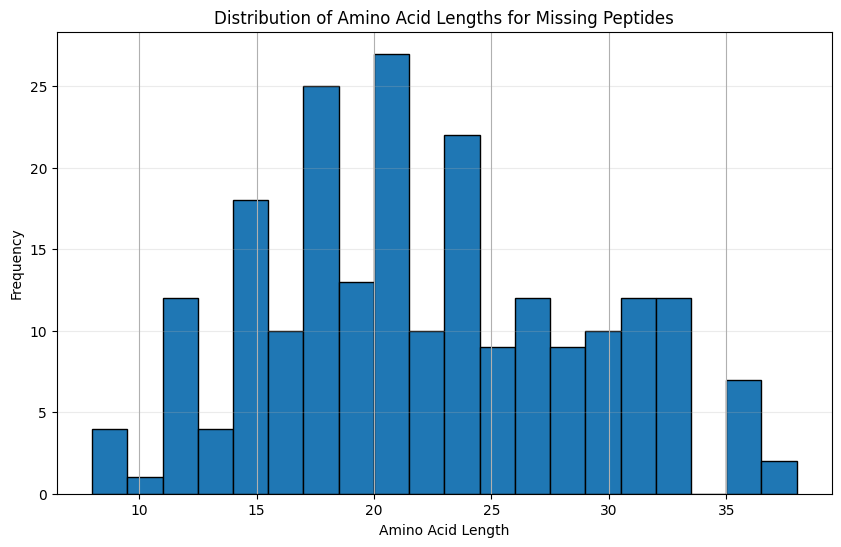

In [5]:
print("All Missing")
display(comparison_df.loc[comparison_df["status"] == "missing", display_cols])

import matplotlib.pyplot as plt

missing_df = comparison_df.loc[comparison_df["status"] == "missing"]

plt.figure(figsize=(10, 6))
missing_df["paper_length"].hist(bins=20, edgecolor="black")
plt.title("Distribution of Amino Acid Lengths for Missing Peptides")
plt.xlabel("Amino Acid Length")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.25)
plt.show()

## Missing Candidates Analysis

This plot analyzes the "near matches" to mathematically demonstrate why the pipeline picked slightly different overlapping boundaries. It compares how much longer the generated sequences are (`length_delta`) against how much their score was inflated under the fractional hydrophobicity metric.

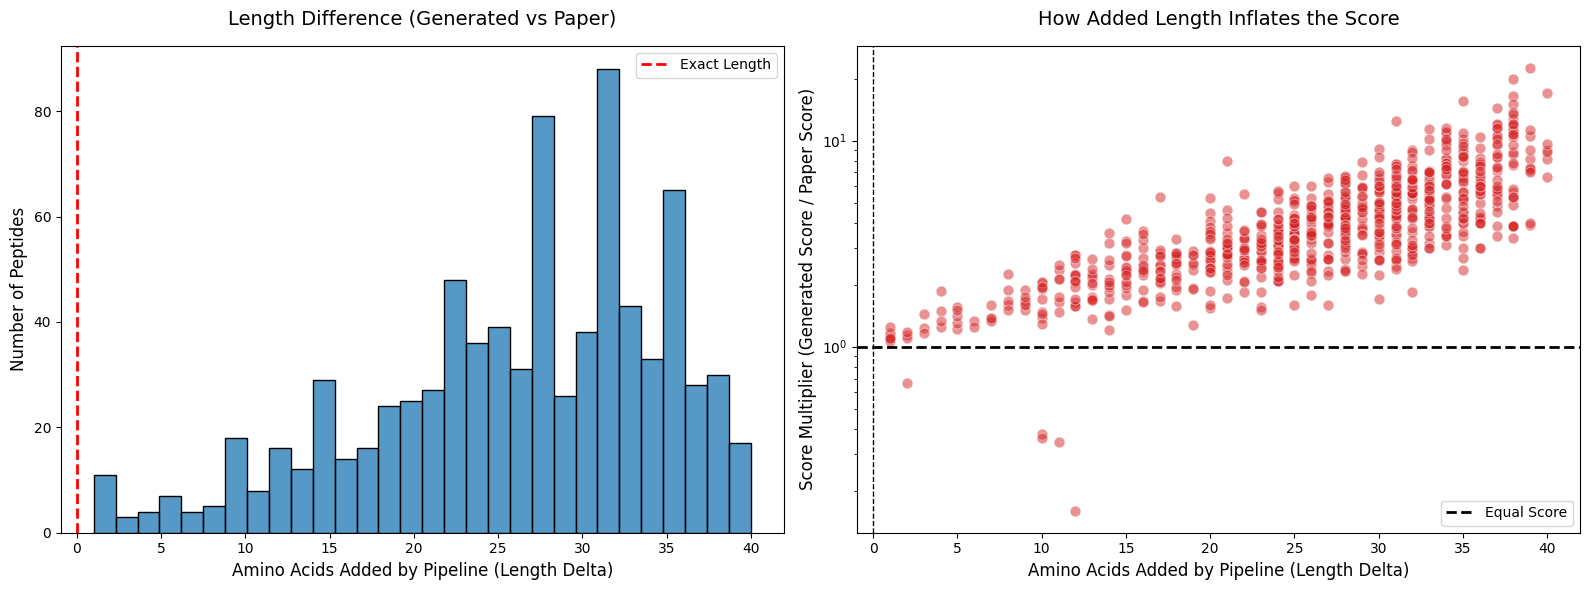

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("sequence_to_svm_minimal"))
sys.path.append(os.path.abspath("../sequence_to_svm_minimal"))
from proteome_candidate_generator.pddp_scoring import PaneScorer

scorer = PaneScorer()

# Filter to near matches where we have both sequences
near_df = comparison_df[comparison_df['status'] == 'near'].copy()

def get_score(seq):
    try: return scorer.score_sequence(seq)
    except: return 0.0

# Calculate scores for both
near_df['paper_score'] = near_df['paper_sequence'].apply(get_score)
near_df['gen_score'] = near_df['generated_sequence'].apply(get_score)

# Calculate score multiplier (how much the score increased by picking the generated variant)
near_df['score_multiplier'] = near_df['gen_score'] / near_df['paper_score'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribution of Length Deltas
sns.histplot(data=near_df, x='length_delta', bins=30, ax=axes[0], color='#1f77b4', edgecolor='black')
axes[0].set_title('Length Difference (Generated vs Paper)', fontsize=14, pad=15)
axes[0].set_xlabel('Amino Acids Added by Pipeline (Length Delta)', fontsize=12)
axes[0].set_ylabel('Number of Peptides', fontsize=12)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Exact Length')
axes[0].legend()

# Plot 2: Length Delta vs Score Multiplier
sns.scatterplot(data=near_df, x='length_delta', y='score_multiplier', alpha=0.5, ax=axes[1], color='#d62728', s=60)
axes[1].set_title('How Added Length Inflates the Score', fontsize=14, pad=15)
axes[1].set_xlabel('Amino Acids Added by Pipeline (Length Delta)', fontsize=12)
axes[1].set_ylabel('Score Multiplier (Generated Score / Paper Score)', fontsize=12)
axes[1].axhline(1, color='black', linestyle='--', linewidth=2, label='Equal Score')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()


## Missing Peptides Overlap Analysis

This analysis proves that the "missing" peptides are not actually missing from the generated dataset. Instead, they share significant partial overlaps with the generated peptides. By measuring the Longest Common Substring (LCS) between each missing peptide and the generated dataset, we can see what percentage of the original peptide's sequence was successfully recovered before the overlap policy shifted the boundaries.

Analyzing 219 missing sequences...


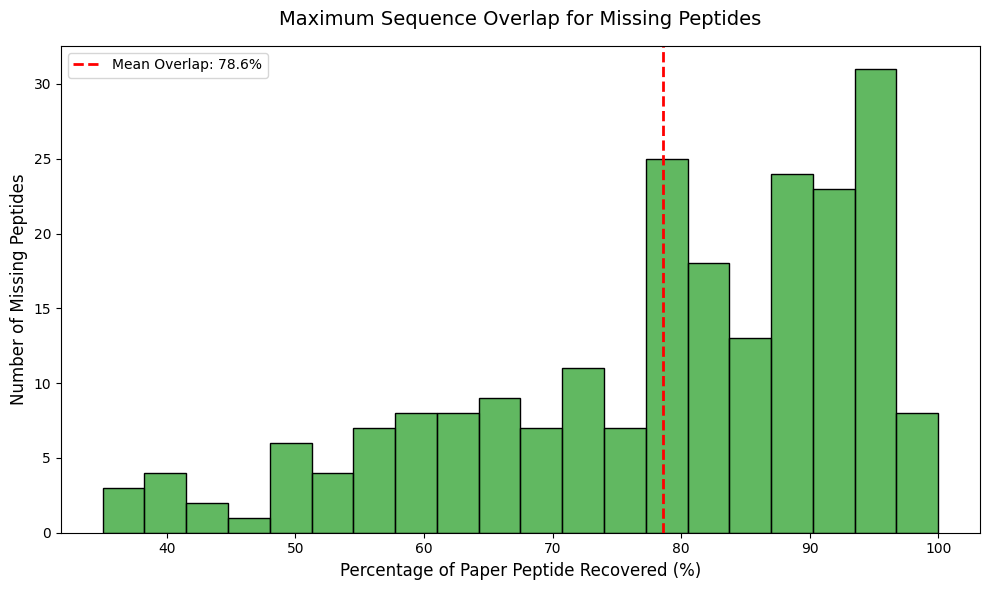

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np

# 1. Identify the missing sequences
missing_seqs = comparison_df.loc[comparison_df['status'] == 'missing', 'paper_sequence'].tolist()
gen_seqs = generated_sequences.tolist()

print(f"Analyzing {len(missing_seqs)} missing sequences...")

# 2. Build a fast 5-mer index of the generated sequences to avoid O(N^2) comparisons
k = 5
index = defaultdict(list)
for i, g_seq in enumerate(gen_seqs):
    for j in range(len(g_seq) - k + 1):
        index[g_seq[j:j+k]].append(i)

# 3. Helper function to find the longest common substring
def longest_common_substring(s1, s2):
    m = [[0] * (1 + len(s2)) for _ in range(1 + len(s1))]
    longest = 0
    for x in range(1, 1 + len(s1)):
        for y in range(1, 1 + len(s2)):
            if s1[x - 1] == s2[y - 1]:
                m[x][y] = m[x - 1][y - 1] + 1
                if m[x][y] > longest:
                    longest = m[x][y]
            else:
                m[x][y] = 0
    return longest

# 4. Calculate max overlap percentage for each missing sequence
overlap_pcts = []
for p_seq in missing_seqs:
    candidates = set()
    for j in range(len(p_seq) - k + 1):
        kmer = p_seq[j:j+k]
        candidates.update(index.get(kmer, []))
    
    max_overlap = 0
    for idx in candidates:
        g_seq = gen_seqs[idx]
        overlap = longest_common_substring(p_seq, g_seq)
        if overlap > max_overlap:
            max_overlap = overlap
            
    # If no 5-mer matched, the overlap is extremely small (< 5 amino acids)
    if not candidates:
        # Fallback to full search just in case
        for g_seq in gen_seqs:
            overlap = longest_common_substring(p_seq, g_seq)
            if overlap > max_overlap:
                max_overlap = overlap
                
    overlap_pcts.append((max_overlap / len(p_seq)) * 100)

# 5. Plot the results
plt.figure(figsize=(10, 6))
sns.histplot(overlap_pcts, bins=20, color='#2ca02c', edgecolor='black')
plt.title('Maximum Sequence Overlap for Missing Peptides', fontsize=14, pad=15)
plt.xlabel('Percentage of Paper Peptide Recovered (%)', fontsize=12)
plt.ylabel('Number of Missing Peptides', fontsize=12)
plt.axvline(np.mean(overlap_pcts), color='red', linestyle='--', linewidth=2, 
            label=f'Mean Overlap: {np.mean(overlap_pcts):.1f}%')
plt.legend()
plt.tight_layout()
plt.show()
